# Các Thông Số Cơ Bản Của Thống Kê Dữ Liệu Nhiều Biến

Notebook này sẽ trình bày cách tính toán các thông số thống kê cơ bản cho dữ liệu nhiều biến (multivariate data), bao gồm vector trung bình, ma trận hiệp phương sai và ma trận tương quan. Dữ liệu đầu vào là một ma trận $n \times p$, trong đó $n$ là số lượng quan sát (items) và $p$ là số lượng biến (variables).

## 1. Import Libraries

Để thực hiện các phép tính toán ma trận, chúng ta sẽ sử dụng thư viện `NumPy`.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

## 2. Generate Sample Multivariate Data

Chúng ta sẽ tạo ngẫu nhiên một ma trận dữ liệu $n \times p$ với $n \approx 50$ quan sát và $p = 3$ biến để mô phỏng các phép tính phía sau.

In [22]:
# Load Iris dataset
iris = load_iris()

# Ma trận đầu vào n x p (n=150, p=4)
data = iris.data.astype(float)
target = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

# Nếu bạn chỉ muốn 3 biến để giữ giống notebook cũ:
# data = iris.data[:, :3].astype(float)

n, p = data.shape

print(f"Iris data matrix: {n} observations, {p} variables")
print("Feature names:", feature_names)
print("Target names:", target_names)
print(data[:5])  # xem 5 dòng đầu

Iris data matrix: 150 observations, 4 variables
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


## 3. Calculate Mean Vector

Vector trung bình $\bar{\mathbf{x}} = [\bar{x}_1, \bar{x}_2, \ldots, \bar{x}_p]^T$ được tính bằng cách lấy trung bình của từng biến: $\bar{x}_j = \frac{1}{n} \sum_{i=1}^{n} x_{ij}$.

In [23]:
mean_vector = np.zeros(p, dtype=float)
for j in range(p):
    column_sum = 0.0
    for i in range(n):
        column_sum += data[i, j]
    mean_vector[j] = column_sum / n

print("Mean Vector:")
print(mean_vector)

Mean Vector:
[5.84333333 3.05733333 3.758      1.19933333]


## 4. Calculate Variance Vector

Phương sai mẫu của từng biến phản ánh mức độ phân tán riêng lẻ: $s_j^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_{ij} - \bar{x}_j)^2$. Ta sẽ tự triển khai công thức này thông qua các vòng lặp.

In [24]:
variance_vector = np.zeros(p, dtype=float)
for j in range(p):
    accum = 0.0
    for i in range(n):
        diff = data[i, j] - mean_vector[j]
        accum += diff * diff
    variance_vector[j] = accum / (n - 1)

print("Variance Vector (sample variance for each variable):")
print(variance_vector)

Variance Vector (sample variance for each variable):
[0.68569351 0.18997942 3.11627785 0.58100626]


## 5. Calculate Covariance Matrix

Ma trận hiệp phương sai $S$ đo lường mức độ biến thiên cùng nhau của các biến và được tính bằng: $S_{jk} = \frac{1}{n-1} \sum_{i=1}^{n} (x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)$.

In [25]:
cov_matrix = np.zeros((p, p), dtype=float)
for j in range(p):
    for k in range(p):
        accum = 0.0
        for i in range(n):
            diff_j = data[i, j] - mean_vector[j]
            diff_k = data[i, k] - mean_vector[k]
            accum += diff_j * diff_k
        cov_matrix[j, k] = accum / (n - 1)

print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[ 0.68569351 -0.042434    1.27431544  0.51627069]
 [-0.042434    0.18997942 -0.32965638 -0.12163937]
 [ 1.27431544 -0.32965638  3.11627785  1.2956094 ]
 [ 0.51627069 -0.12163937  1.2956094   0.58100626]]


## 6. Calculate Correlation Matrix

Ma trận hệ số tương quan $R$ chuẩn hóa hiệp phương sai về khoảng $[-1, 1]$: $R_{jk} = \frac{S_{jk}}{\sqrt{S_{jj} S_{kk}}}$. Ta sẽ tính toán thủ công dựa trên ma trận hiệp phương sai và vector phương sai đã có.

In [26]:
corr_matrix = np.zeros((p, p), dtype=float)
for j in range(p):
    for k in range(p):
        denom = (variance_vector[j] * variance_vector[k]) ** 0.5
        if denom == 0:
            corr_matrix[j, k] = 0.0
        else:
            corr_matrix[j, k] = cov_matrix[j, k] / denom

print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
[[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]


## 7. Visualize Summary Statistics

Biểu diễn trực quan giúp nhận biết nhanh các mẫu hình giữa các biến. Ở đây ta minh họa:
- Biểu đồ cột cho vector trung bình và phương sai.
- Heatmap cho ma trận hiệp phương sai và hệ số tương quan.

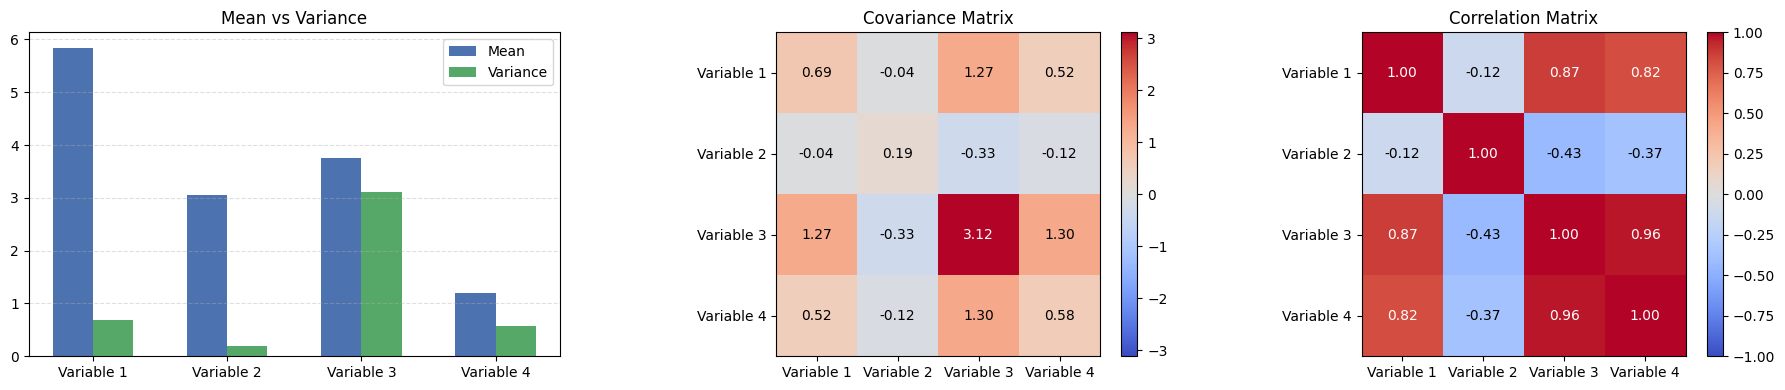

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
var_labels = [f"Variable {idx+1}" for idx in range(p)]
positions = np.arange(p)

# Bar chart to compare mean vs variance magnitude per variable
axes[0].bar(positions - 0.15, mean_vector, width=0.3, label="Mean", color="#4C72B0")
axes[0].bar(positions + 0.15, variance_vector, width=0.3, label="Variance", color="#55A868")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(var_labels)
axes[0].set_title("Mean vs Variance")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

heatmap_targets = [
    (cov_matrix, "Covariance Matrix"),
    (corr_matrix, "Correlation Matrix")
]

for ax, (matrix, title) in zip(axes[1:], heatmap_targets):
    scale = np.max(np.abs(matrix)) or 1.0
    im = ax.imshow(matrix, cmap="coolwarm", vmin=-scale, vmax=scale)
    ax.set_xticks(positions)
    ax.set_yticks(positions)
    ax.set_xticklabels(var_labels)
    ax.set_yticklabels(var_labels)
    ax.set_title(title)
    for row in range(p):
        for col in range(p):
            value = matrix[row, col]
            text_color = "white" if abs(value) > scale * 0.5 else "black"
            ax.text(col, row, f"{value:.2f}", ha="center", va="center", color=text_color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 8. Hình Học Của Các Thông Số

- Vector trung bình là tâm hình học (centroid) của đám mây điểm.
- Ma trận hiệp phương sai mô tả hình dạng ellip bao trùm dữ liệu thông qua các trị riêng.
- Ma trận tương quan giữ nguyên hướng ellip nhưng thu nhỏ theo độ dài chuẩn hóa.

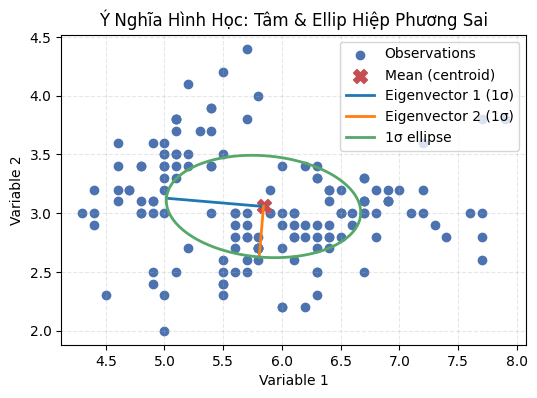

In [28]:
if p < 2:
    print("Cần ít nhất 2 biến để minh hoạ hình học trong mặt phẳng.")
else:
    mean_2d = mean_vector[:2]
    cov_2d = cov_matrix[:2, :2]
    data_2d = data[:, :2]

    def eigen_decomposition_2x2(matrix_2x2):
        a = matrix_2x2[0, 0]
        b = matrix_2x2[0, 1]
        c = matrix_2x2[1, 0]
        d = matrix_2x2[1, 1]
        trace = a + d
        determinant = a * d - b * c
        discriminant = trace * trace - 4.0 * determinant
        discriminant = discriminant if discriminant > 0 else 0.0
        sqrt_disc = discriminant ** 0.5
        lambda1 = 0.5 * (trace + sqrt_disc)
        lambda2 = 0.5 * (trace - sqrt_disc)

        def normalize(vec):
            norm = (vec[0] * vec[0] + vec[1] * vec[1]) ** 0.5
            if norm == 0:
                return np.array([1.0, 0.0], dtype=float)
            return vec / norm

        vec1 = np.array([b, lambda1 - a], dtype=float)
        if abs(vec1[0]) < 1e-10 and abs(vec1[1]) < 1e-10:
            vec1 = np.array([lambda1 - d, c], dtype=float)
        vec1 = normalize(vec1)
        vec2 = np.array([-vec1[1], vec1[0]], dtype=float)

        eigenvalues = np.array([lambda1, lambda2], dtype=float)
        eigenvectors = np.zeros((2, 2), dtype=float)
        for row in range(2):
            eigenvectors[row, 0] = vec1[row]
            eigenvectors[row, 1] = vec2[row]
        return eigenvalues, eigenvectors

    eigen_vals, eigen_vecs = eigen_decomposition_2x2(cov_2d)
    std_lengths = np.zeros(2, dtype=float)
    for idx in range(2):
        std_lengths[idx] = eigen_vals[idx] if eigen_vals[idx] > 0 else 0.0
        std_lengths[idx] = std_lengths[idx] ** 0.5

    angle_samples = np.linspace(0, 2 * np.pi, 200)
    ellipse_points = np.zeros((angle_samples.size, 2), dtype=float)
    for idx, angle in enumerate(angle_samples):
        unit_circle = np.array([np.cos(angle), np.sin(angle)], dtype=float)
        scaled = np.zeros(2, dtype=float)
        for j in range(2):
            scaled[j] = std_lengths[j] * unit_circle[j]
        transformed = np.zeros(2, dtype=float)
        for row in range(2):
            for col in range(2):
                transformed[row] += eigen_vecs[row, col] * scaled[col]
        ellipse_points[idx] = mean_2d + transformed

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(data_2d[:, 0], data_2d[:, 1], color="#4C72B0", label="Observations")
    ax.scatter(mean_2d[0], mean_2d[1], color="#C44E52", marker="X", s=100, label="Mean (centroid)")

    for idx in range(2):
        direction = np.zeros(2, dtype=float)
        for row in range(2):
            direction[row] = eigen_vecs[row, idx] * std_lengths[idx]
        ax.plot(
            [mean_2d[0], mean_2d[0] + direction[0]],
            [mean_2d[1], mean_2d[1] + direction[1]],
            linewidth=2,
            label=f"Eigenvector {idx+1} (1σ)"
        )

    ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], color="#55A868", linewidth=2, label="1σ ellipse")
    ax.set_xlabel("Variable 1")
    ax.set_ylabel("Variable 2")
    ax.set_title("Ý Nghĩa Hình Học: Tâm & Ellip Hiệp Phương Sai")
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_aspect("equal", adjustable="box")
    plt.show()

## 9. Advanced Multivariate Visualizations (Iris)

Phần này minh họa thêm các kỹ thuật trực quan hóa dữ liệu nhiều biến trên Iris dataset:

- Dot diagrams + scatter plot
- Multiple scatter plot (scatter matrix)
- 3D scatter plot theo nhóm
- Growth curves
- Stars
- Chernoff faces

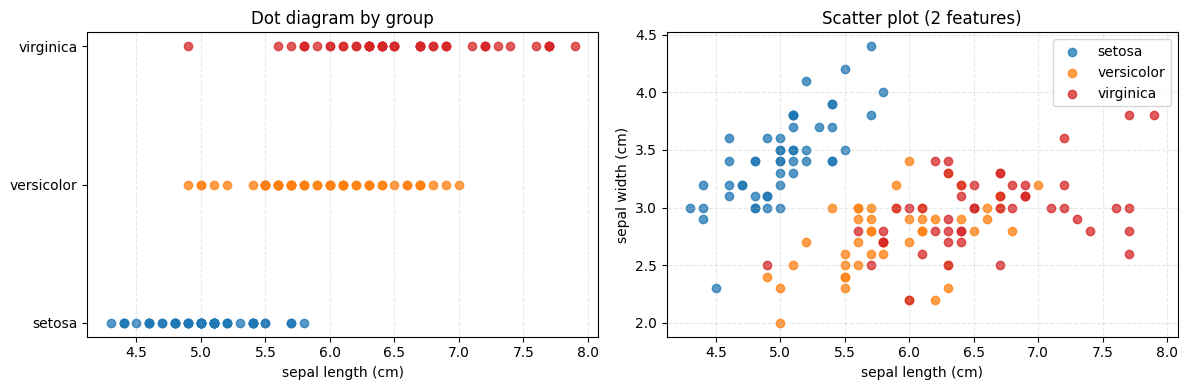

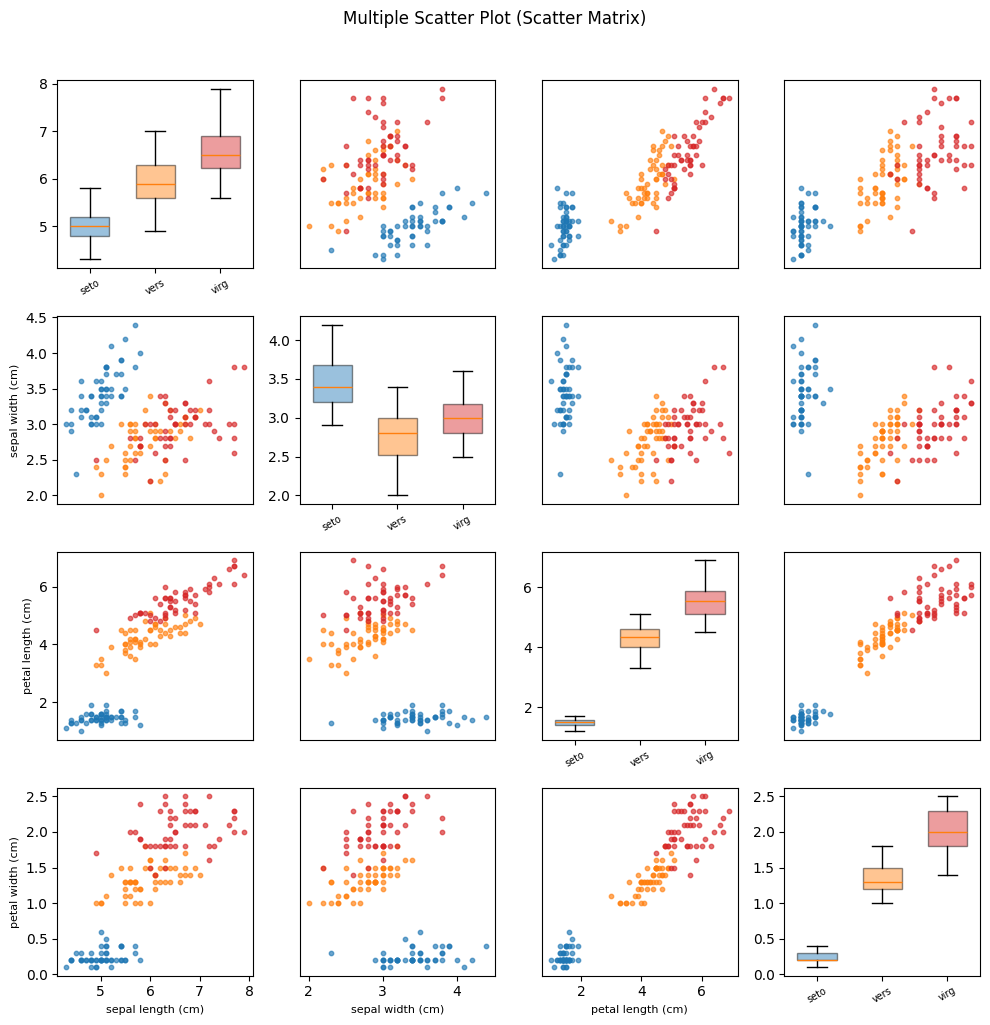

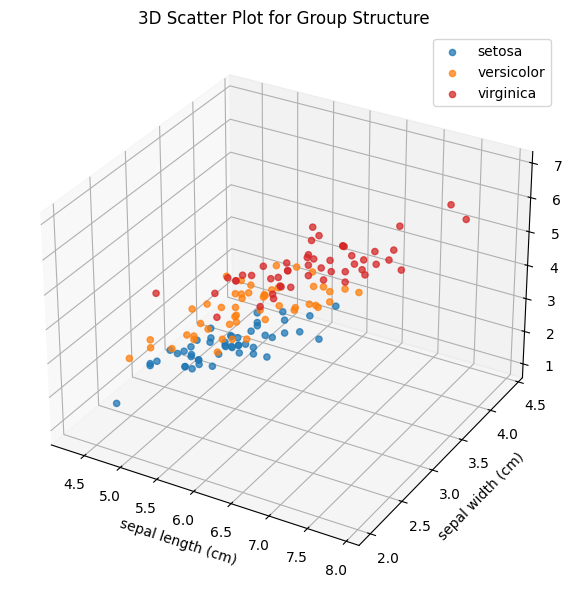

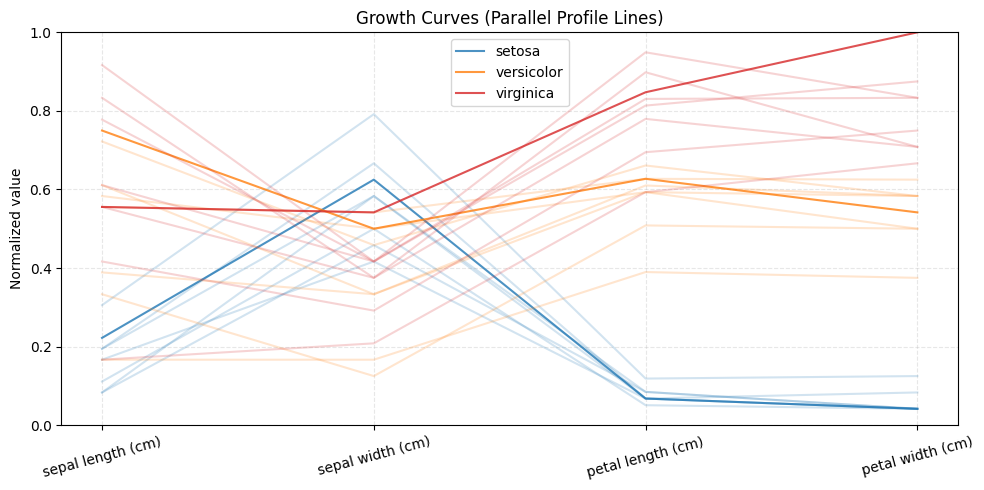

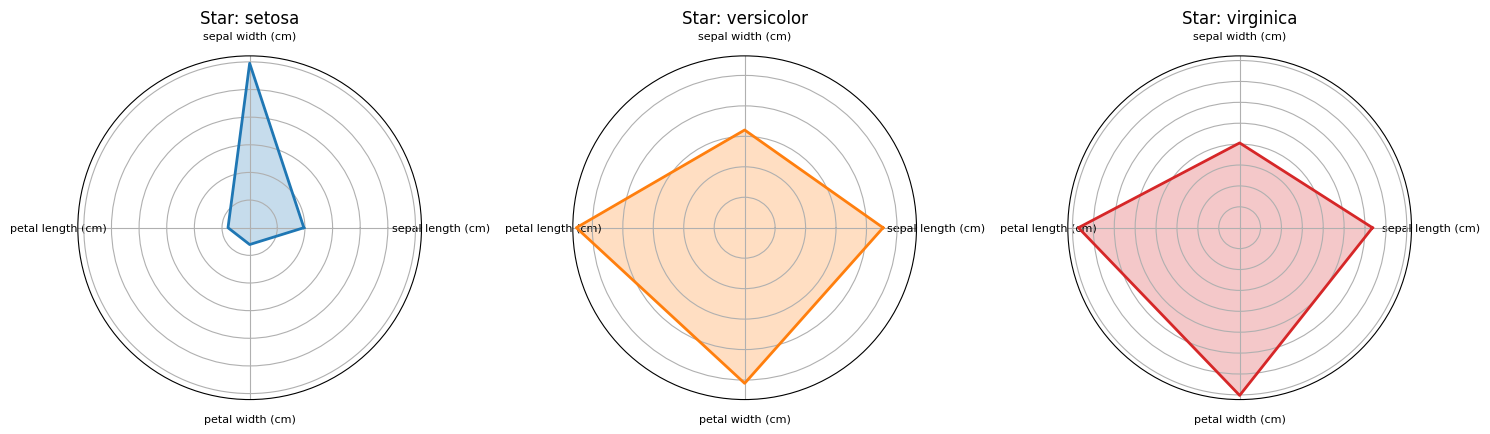

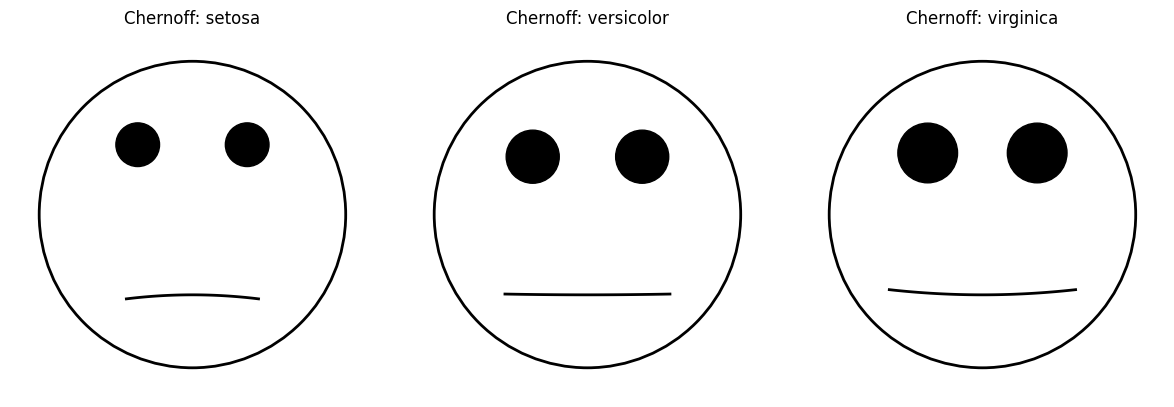

In [31]:
# Chuẩn hóa dữ liệu về [0, 1] để dùng cho nhiều biểu đồ dạng profile
mins = data.min(axis=0)
maxs = data.max(axis=0)
ranges = maxs - mins
ranges[ranges == 0] = 1.0
data_norm = (data - mins) / ranges

# setosa: xanh dương, versicolor: cam, virginica: đỏ
colors = ["#1f77b4", "#ff7f0e", "#d62728"]
labels = [target_names[i] for i in target]

# 1) Dot diagrams + Scatter plot (2 biến đầu)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for g, color in enumerate(colors):
    mask = target == g
    axes[0].scatter(data[mask, 0], np.full(mask.sum(), g), alpha=0.75, color=color, label=target_names[g])
axes[0].set_xlabel(feature_names[0])
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(target_names)
axes[0].set_title("Dot diagram by group")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)

for g, color in enumerate(colors):
    mask = target == g
    axes[1].scatter(data[mask, 0], data[mask, 1], alpha=0.75, color=color, label=target_names[g])
axes[1].set_xlabel(feature_names[0])
axes[1].set_ylabel(feature_names[1])
axes[1].set_title("Scatter plot (2 features)")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Multiple scatter plot (scatter matrix thủ công, đường chéo là boxplot)
num_features = data.shape[1]
fig, axes = plt.subplots(num_features, num_features, figsize=(10, 10))
for i in range(num_features):
    for j in range(num_features):
        ax = axes[i, j]
        if i == j:
            grouped_vals = [data[target == g, j] for g in range(len(target_names))]
            bp = ax.boxplot(grouped_vals, patch_artist=True, widths=0.6, showfliers=False)
            for patch, color in zip(bp["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.45)
            ax.set_xticks([1, 2, 3])
            ax.set_xticklabels([name[:4] for name in target_names], fontsize=7, rotation=30)
        else:
            for g, color in enumerate(colors):
                mask = target == g
                ax.scatter(data[mask, j], data[mask, i], s=10, alpha=0.65, color=color)
        if i == num_features - 1 and i != j:
            ax.set_xlabel(feature_names[j], fontsize=8)
        elif i != j:
            ax.set_xticks([])
        if j == 0 and i != j:
            ax.set_ylabel(feature_names[i], fontsize=8)
        elif i != j:
            ax.set_yticks([])
plt.suptitle("Multiple Scatter Plot (Scatter Matrix)", y=1.02)
plt.tight_layout()
plt.show()

# 3) 3D scatter plot (group structure)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
for g, color in enumerate(colors):
    mask = target == g
    ax.scatter(
        data[mask, 0], data[mask, 1], data[mask, 2],
        color=color, alpha=0.75, label=target_names[g]
    )
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_zlabel(feature_names[2])
ax.set_title("3D Scatter Plot for Group Structure")
ax.legend()
plt.tight_layout()
plt.show()

# 4) Graph of growth curves (parallel profiles cho một số quan sát)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(num_features)
sample_per_group = 8
for g, color in enumerate(colors):
    idx = np.where(target == g)[0][:sample_per_group]
    for k, row_idx in enumerate(idx):
        alpha = 0.2 + 0.6 * (k == 0)
        label = target_names[g] if k == 0 else None
        ax.plot(x, data_norm[row_idx], color=color, alpha=alpha, linewidth=1.5, label=label)
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=15)
ax.set_ylim(0, 1)
ax.set_ylabel("Normalized value")
ax.set_title("Growth Curves (Parallel Profile Lines)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# 5) Stars (star glyphs cho trung bình từng nhóm)
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={"projection": "polar"})
for g, ax in enumerate(axes):
    mean_profile = data_norm[target == g].mean(axis=0)
    values = np.concatenate([mean_profile, [mean_profile[0]]])
    ax.plot(angles_closed, values, color=colors[g], linewidth=2)
    ax.fill(angles_closed, values, color=colors[g], alpha=0.25)
    ax.set_xticks(angles)
    ax.set_xticklabels(feature_names, fontsize=8)
    ax.set_yticklabels([])
    ax.set_title(f"Star: {target_names[g]}")
plt.tight_layout()
plt.show()

# 6) Chernoff Faces (vẽ mặt đơn giản từ 4 biến đã chuẩn hóa)
def draw_face(ax, values, title=""):
    # values gồm 4 phần tử trong [0, 1]
    eye_size = 0.05 + 0.05 * values[0]
    eye_y = 0.62 + 0.12 * values[1]
    mouth_curve = -0.4 + 0.8 * values[2]
    mouth_width = 0.35 + 0.2 * values[3]

    face = plt.Circle((0.5, 0.5), 0.42, fill=False, linewidth=2)
    ax.add_patch(face)

    left_eye = plt.Circle((0.35, eye_y), eye_size, color="black")
    right_eye = plt.Circle((0.65, eye_y), eye_size, color="black")
    ax.add_patch(left_eye)
    ax.add_patch(right_eye)

    xs = np.linspace(0.5 - mouth_width / 2, 0.5 + mouth_width / 2, 100)
    ys = 0.28 + mouth_curve * (xs - 0.5) ** 2
    ax.plot(xs, ys, color="black", linewidth=2)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

group_means = np.array([data_norm[target == g].mean(axis=0) for g in range(3)])
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for g, ax in enumerate(axes):
    draw_face(ax, group_means[g], title=f"Chernoff: {target_names[g]}")
plt.tight_layout()
plt.show()

## 10. t-SNE Visualization

t-SNE (t-distributed Stochastic Neighbor Embedding) giúp biểu diễn dữ liệu nhiều chiều về 2D để quan sát cấu trúc nhóm. Vì t-SNE nhạy với scale, ta chuẩn hóa dữ liệu trước khi giảm chiều.

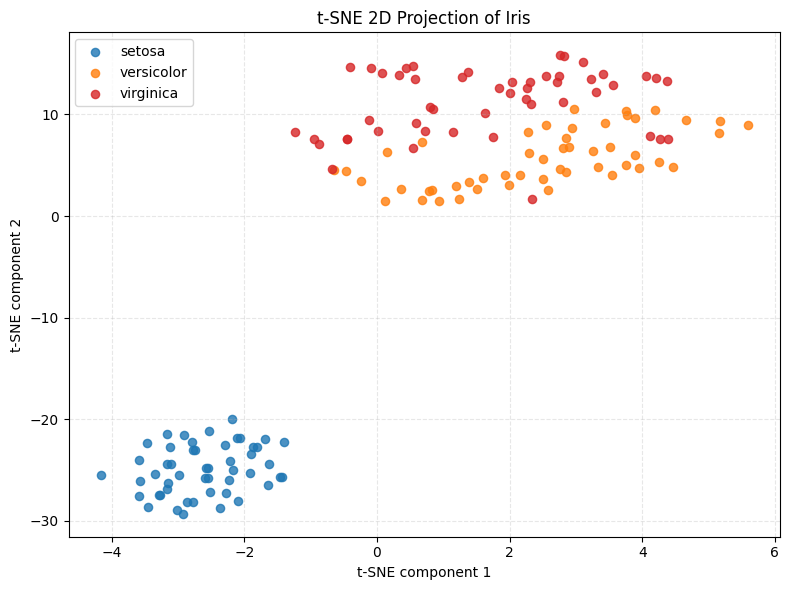

In [32]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa trước khi chạy t-SNE
X_scaled = StandardScaler().fit_transform(data)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
    )
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for g, color in enumerate(colors):
    mask = target == g
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        color=color, alpha=0.8, s=35, label=target_names[g]
    )
ax.set_title("t-SNE 2D Projection of Iris")
ax.set_xlabel("t-SNE component 1")
ax.set_ylabel("t-SNE component 2")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()